In [1]:
!pip install bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.6 MB/s eta 0:00:00


In [2]:
%%writefile train_snli_ddp.py
import os
import math
import json
import copy
import random
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_cosine_schedule_with_warmup,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from torch.optim.swa_utils import AveragedModel

# Scikit-learn is ONLY used at the very end for the final confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

# DDP and High-Speed Metrics
from accelerate import Accelerator
from accelerate.utils import DistributedDataParallelKwargs
import torchmetrics

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Seed only the CPU globally. Accelerate handles GPU seeding natively.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

def print_gpu_mem(accelerator):
    if torch.cuda.is_available() and accelerator.is_main_process:
        for i in range(torch.cuda.device_count()):
            alloc = torch.cuda.memory_allocated(i) / 1024**3
            reserved = torch.cuda.memory_reserved(i) / 1024**3
            print(f"GPU {i}: allocated={alloc:.2f} GB | reserved={reserved:.2f} GB", flush=True)

# ============================================================
# SECTION 2: Configuration 
# ============================================================
DEBUG_MODE = False # Set False for full 50k-step run

# --- NEW: TIMEOUT & RESUME PATHS ---
RESUME_FROM_CHECKPOINT = False # Set to True to load weights from RESUME_WEIGHTS_DIR
RESUME_WEIGHTS_DIR    = "/kaggle/input/models/kapilsandhu2022/v1-4-1-full-run/other/default/1/qwen25_snli_ddp_output/last_model"
MAX_TRAINING_TIME_SEC = 40000 # Graceful timeout limit (approx 11.1 hours)

MODEL_NAME   = "Qwen/Qwen2.5-0.5B"
DATASET_NAME = "stanfordnlp/snli"

NUM_LABELS = 3
LABEL2ID   = {"entailment": 0, "neutral": 1, "contradiction": 2}
ID2LABEL   = {0: "entailment", 1: "neutral", 2: "contradiction"}

# Debug Slices
DEBUG_TRAIN_SIZE = 10000
DEBUG_VAL_SIZE   = 1000
DEBUG_TEST_SIZE  = 1000

# Architecture & Hardware
MAX_LENGTH          = 64     
BATCH_SIZE          = 64      # Per GPU (Effective = 256)
GRAD_ACCUM_STEPS    = 2
LEARNING_RATE       = 2e-4    
WEIGHT_DECAY        = 0.01

LORA_R              = 64  
LORA_ALPHA          = 128
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# Step-Based Targets
MAX_STEPS           = 240 if DEBUG_MODE else 12000 
PRINT_EVERY         = 20
EVAL_EVERY          = 60 if DEBUG_MODE else 500

OUTPUT_DIR       = "/kaggle/working/qwen25_snli_ddp_output"
WEIGHTS_DIR      = f"{OUTPUT_DIR}/best_model"
METRICS_FILE     = f"{OUTPUT_DIR}/metrics_log.txt"
LAST_WEIGHTS_DIR = f"{OUTPUT_DIR}/last_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(LAST_WEIGHTS_DIR, exist_ok=True)

# ============================================================
# MAIN MULTI-GPU TRAINING LOOP
# ============================================================
def main_training_loop():
    
    # Fix for Unused Parameters in Qwen sequence classification
    ddp_kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
    accelerator = Accelerator(gradient_accumulation_steps=GRAD_ACCUM_STEPS, kwargs_handlers=[ddp_kwargs])
    
    accelerator.print(f"PyTorch : {torch.__version__}")
    accelerator.print(f"GPUs active: {accelerator.num_processes}")

    # ============================================================
    # SECTION 3: Dataset Loading & Tokenization
    # ============================================================
    with accelerator.main_process_first():
        accelerator.print(f"\nLoading SNLI and Tokenizer (MAX_LENGTH={MAX_LENGTH})...")
        raw_dataset = load_dataset(DATASET_NAME)
        raw_dataset = raw_dataset.filter(lambda x: x["label"] != -1)

        if DEBUG_MODE:
            accelerator.print(f"\n>>> DEBUG MODE ACTIVE: Truncating dataset for fast {MAX_STEPS}-step test <<<")
            raw_dataset["train"] = raw_dataset["train"].shuffle(seed=SEED).select(range(min(DEBUG_TRAIN_SIZE, len(raw_dataset["train"]))))
            raw_dataset["validation"] = raw_dataset["validation"].shuffle(seed=SEED).select(range(min(DEBUG_VAL_SIZE, len(raw_dataset["validation"]))))
            raw_dataset["test"] = raw_dataset["test"].shuffle(seed=SEED).select(range(min(DEBUG_TEST_SIZE, len(raw_dataset["test"]))))

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, padding_side="left")
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            tokenizer.pad_token_id = tokenizer.eos_token_id

        def preprocess_function(examples):
            texts = [f"Premise: {p}\nHypothesis: {h}\nRelationship:" for p, h in zip(examples["premise"], examples["hypothesis"])]
            tokenized = tokenizer(texts, truncation=True, max_length=MAX_LENGTH, padding=False)
            tokenized["labels"] = examples["label"]
            return tokenized

        tokenized_datasets = raw_dataset.map(preprocess_function, batched=True, remove_columns=["premise", "hypothesis", "label"])
        tokenized_datasets.set_format("torch")

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)
    
    # --- SMART BATCHING IMPLEMENTATION ---
    class SmartLengthSampler(torch.utils.data.Sampler):
        def __init__(self, dataset, global_batch_size):
            self.dataset = dataset
            self.global_batch_size = global_batch_size
            self.lengths = [len(x) for x in dataset["input_ids"]]

        def __iter__(self):
            noisy_lengths = np.array(self.lengths) + np.random.uniform(-2, 2, len(self.lengths))
            indices = np.argsort(noisy_lengths)
            batches = [indices[i : i + self.global_batch_size] for i in range(0, len(indices), self.global_batch_size)]
            np.random.shuffle(batches)
            flattened = [idx for batch in batches for idx in batch]
            return iter(flattened)

        def __len__(self):
            return len(self.dataset)

    global_batch_size = BATCH_SIZE * accelerator.num_processes
    train_sampler = SmartLengthSampler(tokenized_datasets["train"], global_batch_size)
    
    train_loader = DataLoader(tokenized_datasets["train"], batch_size=BATCH_SIZE, sampler=train_sampler, collate_fn=data_collator, num_workers=1, prefetch_factor=2, pin_memory=True)
    val_loader = DataLoader(tokenized_datasets["validation"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, num_workers=1, prefetch_factor=2, pin_memory=True)
    test_loader = DataLoader(tokenized_datasets["test"], batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, num_workers=1,prefetch_factor=2, pin_memory=True)

    # ============================================================
    # SECTION 4: Model + LoRA (WITH RESUME LOGIC)
    # ============================================================
    accelerator.print("\nLoading base model...")
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
        trust_remote_code=True, ignore_mismatched_sizes=True, attn_implementation="sdpa"
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id
    base_model.config.use_cache = False

    # --- UPDATED: RESUME LOGIC USING SPECIFIC UPLOAD FOLDER ---
    if RESUME_FROM_CHECKPOINT and os.path.exists(RESUME_WEIGHTS_DIR):
        accelerator.print(f"\n---> RESUMING TRAINING from uploaded model: {RESUME_WEIGHTS_DIR} <---")
        model = PeftModel.from_pretrained(base_model, RESUME_WEIGHTS_DIR, is_trainable=True)
    else:
        accelerator.print("\n---> Initializing FRESH LoRA weights <---")
        lora_config = LoraConfig(
            r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=LORA_TARGET_MODULES, 
            lora_dropout=LORA_DROPOUT, bias="none", task_type=TaskType.SEQ_CLS,
        )
        model = get_peft_model(base_model, lora_config)

        for name, param in model.named_parameters():
            if "score" in name or "classifier" in name:
                param.requires_grad = True

        for name, module in model.named_modules():
            if isinstance(module, nn.Linear) and ("score" in name or "classifier" in name):
                nn.init.normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
                break

    # ============================================================
    # SECTION 5: Optimizer and Scheduler
    # ============================================================
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    ema_model = AveragedModel(model)
    
    # LR Floor Trick
    warmup_steps = max(1, int(0.05 * MAX_STEPS))
    scheduler_steps = int(MAX_STEPS * 1.2)
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=scheduler_steps)
    
    criterion = nn.CrossEntropyLoss()

    model, optimizer, train_dl, val_dl, test_dl, scheduler = accelerator.prepare(
        model, optimizer, train_loader, val_loader, test_loader, scheduler
    )

    accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_LABELS).to(accelerator.device)
    f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=NUM_LABELS, average="macro").to(accelerator.device)

    # ============================================================
    # SECTION 6: High-Speed GPU Evaluation Function
    # ============================================================
    @torch.no_grad()
    def evaluate(model, dataloader, split_name="Validation", return_preds=False):
        model.eval()
        total_loss, total_batches = 0.0, 0
        
        if return_preds:
            all_preds, all_labels = [], []

        for batch in dataloader:
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            loss = criterion(outputs.logits.float(), batch["labels"].long())
            preds = torch.argmax(outputs.logits, dim=-1)

            loss_gathered = accelerator.gather(loss)
            total_loss += loss_gathered.mean().item()
            total_batches += 1

            accuracy_metric.update(preds, batch["labels"])
            f1_metric.update(preds, batch["labels"])

            if return_preds:
                preds_gathered, labels_gathered = accelerator.gather_for_metrics((preds, batch["labels"]))
                all_preds.extend(preds_gathered.cpu().numpy().tolist())
                all_labels.extend(labels_gathered.cpu().numpy().tolist())

        acc = accuracy_metric.compute().item()
        f1 = f1_metric.compute().item()
        avg_loss = total_loss / max(1, total_batches)

        accuracy_metric.reset()
        f1_metric.reset()

        accelerator.print(f"[{split_name}] loss={avg_loss:.4f} | acc={acc:.4f} | f1={f1:.4f}")
        
        if return_preds:
            return {"loss": avg_loss, "accuracy": acc, "f1_macro": f1}, all_preds, all_labels
        else:
            return {"loss": avg_loss, "accuracy": acc, "f1_macro": f1}

    # ============================================================
    # SECTION 7: Pure Step-Based Training Loop
    # ============================================================
    best_val_acc, best_step = -1.0, -1
    best_state_dict = None
    
    train_loss_history, val_acc_history, val_loss_history, step_history = [], [], [], []
    global_step = 0
    eval_running_loss, eval_steps_counted = 0.0, 0
    current_train_loss = 0.0

    if accelerator.is_main_process:
        with open(METRICS_FILE, "w" if not RESUME_FROM_CHECKPOINT else "a") as f:
            f.write(f"\nModel: {MODEL_NAME} | Resumed: {RESUME_FROM_CHECKPOINT}\nDataset: {DATASET_NAME}\n\n")

    accelerator.print(f"\nStarting Fast DDP Training (Target: {MAX_STEPS} steps)...")
    
    def get_infinite_batches(dl):
        while True:
            for b in dl:
                yield b
                
    train_iterator = get_infinite_batches(train_dl)
    model.train()
    
    # --- NEW: CLOCK INITIALIZATION ---
    start_time = time.time()

    while global_step < MAX_STEPS:
        
        batch = next(train_iterator)

        with accelerator.accumulate(model):
            outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            loss = criterion(outputs.logits.float(), batch["labels"].long())
            
            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            if global_step % 20 == 0:
                ema_model.update_parameters(model)
                
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        eval_running_loss += loss.item()
        eval_steps_counted += 1

        if accelerator.sync_gradients:
            global_step += 1
            
            # --- NEW: GRACEFUL TIMEOUT CHECK ---
            #if not DEBUG_MODE:
            elapsed_time = time.time() - start_time
            if elapsed_time > MAX_TRAINING_TIME_SEC:
                accelerator.print(f"\n*** GRACEFUL TIMEOUT: Time limit reached ({elapsed_time:.0f}s / {MAX_TRAINING_TIME_SEC}s). Stopping training at step {global_step} to save weights. ***\n")
                break
            
            if global_step % PRINT_EVERY == 0:
                current_train_loss = eval_running_loss / eval_steps_counted
                eval_running_loss, eval_steps_counted = 0.0, 0
                
                if accelerator.is_main_process:
                    accelerator.print(f"[Step {global_step}/{MAX_STEPS}] Train Loss: {current_train_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

            if global_step % EVAL_EVERY == 0:
                
                accelerator.print(f"\n--- Full Evaluation at Step {global_step} ---")
                
                val_metrics = evaluate(model, val_dl, split_name=f"Val-Step-{global_step}", return_preds=False)
                
                if accelerator.is_main_process:
                    print_gpu_mem(accelerator)
                    train_loss_history.append(current_train_loss)
                    step_history.append(global_step)
                    val_acc_history.append(val_metrics["accuracy"])
                    val_loss_history.append(val_metrics["loss"])

                    with open(METRICS_FILE, "a") as f:
                        f.write(f"Step {global_step} / {MAX_STEPS}\n")
                        f.write(f"train_loss: {current_train_loss:.6f}\n")
                        f.write(f"val_loss: {val_metrics['loss']:.6f}\n")
                        f.write(f"val_accuracy: {val_metrics['accuracy']:.6f}\n\n")

                accelerator.wait_for_everyone()
                
                if val_metrics["accuracy"] > best_val_acc:
                    best_val_acc = val_metrics["accuracy"]
                    best_step = global_step
                    best_state_dict = {k: v.detach().cpu().clone() for k, v in ema_model.module.state_dict().items()}

                    if accelerator.is_main_process:
                        accelerator.unwrap_model(model).save_pretrained(WEIGHTS_DIR)
                        tokenizer.save_pretrained(WEIGHTS_DIR)
                        accelerator.print(f"[save] Intermediate model saved at step {best_step} with val_acc={best_val_acc:.4f}\n")

    accelerator.wait_for_everyone()
    
    # ============================================================
    # SECTION 8: Final Saving & Plotting 
    # ============================================================
    if accelerator.is_main_process:
        accelerator.print("\nSaving the final (last) step model...")
        
        # We save the EMA smoothed model as the final Last model
        ema_state_dict = {k: v.detach().cpu().clone() for k, v in ema_model.module.state_dict().items()}
        unwrapped_model = accelerator.unwrap_model(model)
        unwrapped_model.load_state_dict(ema_state_dict)
        
        unwrapped_model.save_pretrained(LAST_WEIGHTS_DIR)
        tokenizer.save_pretrained(LAST_WEIGHTS_DIR)

        accelerator.print("\nGenerating training curves...")
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(step_history, train_loss_history, marker="o", label="Train Loss")
        plt.plot(step_history, val_loss_history, marker="o", color="darkorange", label="Val Loss")
        plt.title("Loss Curves"); plt.xlabel("Global Step"); plt.legend(); plt.grid(alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.plot(step_history, val_acc_history, marker="o", color="green", label="Val Accuracy")
        plt.title("Validation Accuracy"); plt.xlabel("Global Step"); plt.legend(); plt.grid(alpha=0.3)
        plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
        plt.close()

    # ============================================================
    # SECTION 9: Final Test Evaluation
    # ============================================================
    label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]
    
    accelerator.print("\n=== Evaluating LAST Step Model (EMA Matured) ===")
    last_metrics, last_preds, last_labels = evaluate(model, test_dl, split_name="Test-Last", return_preds=True)
    
    accelerator.print("\n=== Restoring and Evaluating BEST Step Model ===")
    unwrapped_model = accelerator.unwrap_model(model)
    if best_state_dict is not None:
        unwrapped_model.load_state_dict(best_state_dict)
    best_metrics, best_preds, best_labels = evaluate(model, test_dl, split_name="Test-Best", return_preds=True)

    if accelerator.is_main_process:
        last_report = classification_report(last_labels, last_preds, target_names=label_names)
        best_report = classification_report(best_labels, best_preds, target_names=label_names)
        
        with open(METRICS_FILE, "a") as f:
            f.write("\n=== FINAL TEST EVALUATION ===\n--- LAST MODEL REPORT ---\n" + last_report + "\n--- BEST MODEL REPORT ---\n" + best_report + "\n")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.heatmap(confusion_matrix(last_labels, last_preds), annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0], cbar=False)
        axes[0].set_title("Confusion Matrix: LAST")
        sns.heatmap(confusion_matrix(best_labels, best_preds), annot=True, fmt="d", cmap="Greens", xticklabels=label_names, yticklabels=label_names, ax=axes[1], cbar=False)
        axes[1].set_title("Confusion Matrix: BEST")
        plt.savefig(f"{OUTPUT_DIR}/confusion_matrices_comparison.png", dpi=150)
        plt.close()
        print("\nTraining Complete. All files saved to:", OUTPUT_DIR)

if __name__ == "__main__":
    main_training_loop()

Writing train_snli_ddp.py


In [3]:
!accelerate launch --multi_gpu --num_processes=2 train_snli_ddp.py

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
PyTorch : 2.10.0+cu128
GPUs active: 2

Loading SNLI and Tokenizer (MAX_LENGTH=64)...
README.md: 16.0kB [00:00, 29.4MB/s]
plain_text/test-00000-of-00001.parquet: 100%|█| 412k/412k [00:00<00:00, 499kB/s]
plain_text/validation-00000-of-00001.par(…): 100%|█| 413k/413k [00:00<00:00, 1.8
plain_text/train-00000-of-00001.parquet: 100%|█| 19.6M/19.6M [00:00<00:00, 27.2M
Generating test split: 100%|███| 10000/10000 [00:00<00:00, 205220.86 examples/s]
Generating validation split: 100%|█| 10000/10000 [00:00<00:00, 1702164.68 exampl
Generating train split: 100%|█| 550152/550152 [00:00<00:00, 2691567.14 examples/
config.json: 100%|█████████████████████████████| 681/68

 1. TRAINING & VALIDATION CURVES (BY STEP)


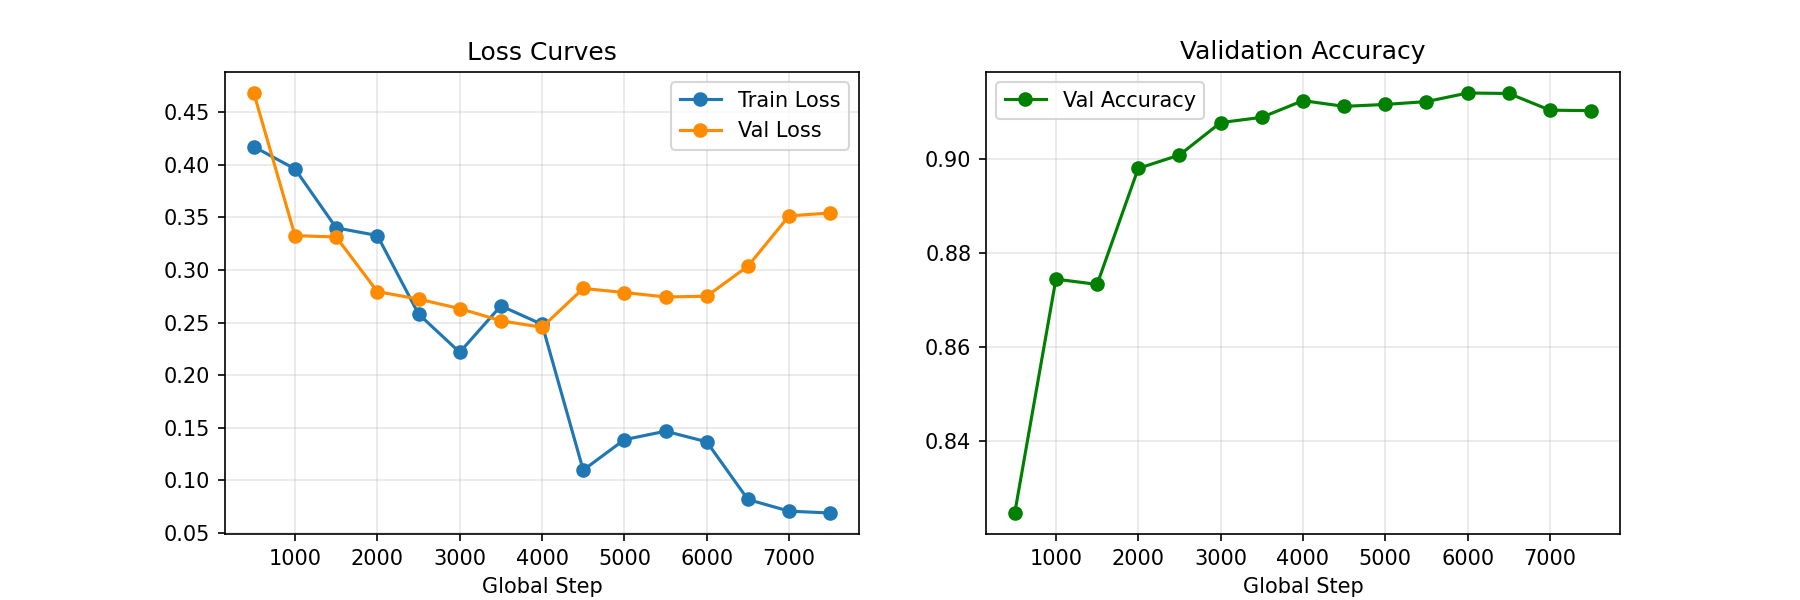


 2. CONFUSION MATRICES (LAST VS BEST MODEL)


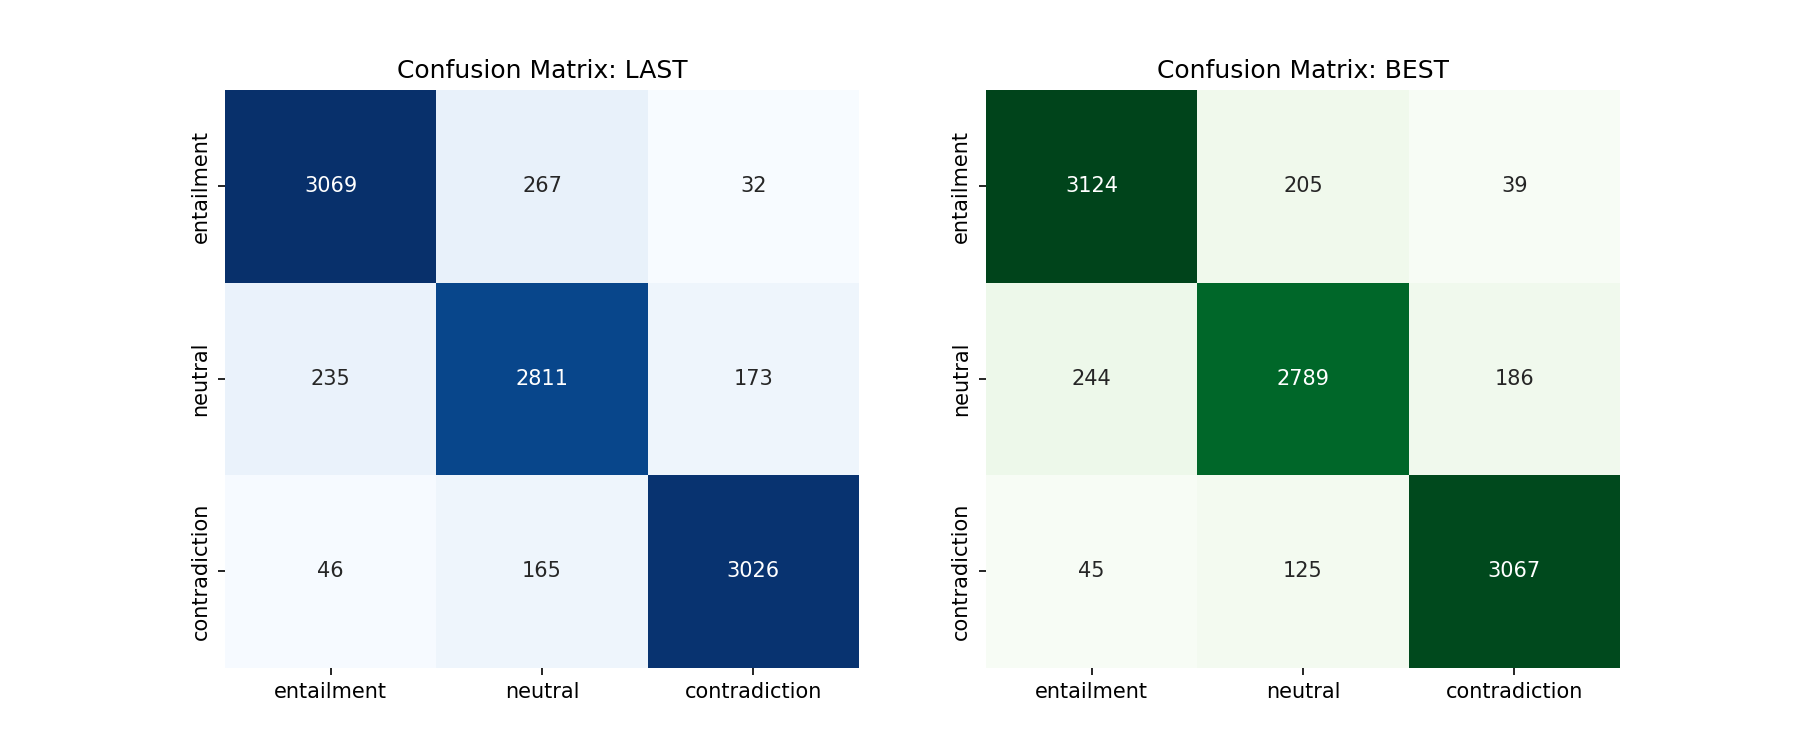


 3. DETAILED METRICS LOG


=== FINAL TEST EVALUATION ===
--- LAST MODEL REPORT ---
               precision    recall  f1-score   support

   entailment       0.92      0.91      0.91      3368
      neutral       0.87      0.87      0.87      3219
contradiction       0.94      0.93      0.94      3237

     accuracy                           0.91      9824
    macro avg       0.91      0.91      0.91      9824
 weighted avg       0.91      0.91      0.91      9824

--- BEST MODEL REPORT ---
               precision    recall  f1-score   support

   entailment       0.92      0.93      0.92      3368
      neutral       0.89      0.87      0.88      3219
contradiction       0.93      0.95      0.94      3237

     accuracy                           0.91      9824
    macro avg       0.91      0.91      0.91      9824
 weighted avg       0.91      0.91      0.91      9824




In [4]:
import os
from IPython.display import Image, display

OUTPUT_DIR = "/kaggle/working/qwen25_snli_ddp_output"

print("==================================================")
print(" 1. TRAINING & VALIDATION CURVES (BY STEP)")
print("==================================================")
display(Image(filename=f"{OUTPUT_DIR}/training_curves.png"))

print("\n==================================================")
print(" 2. CONFUSION MATRICES (LAST VS BEST MODEL)")
print("==================================================")
display(Image(filename=f"{OUTPUT_DIR}/confusion_matrices_comparison.png"))

print("\n==================================================")
print(" 3. DETAILED METRICS LOG")
print("==================================================")
try:
    with open(f"{OUTPUT_DIR}/metrics_log.txt", "r") as f:
        lines = f.readlines()
        print("".join(lines[-25:]))
except FileNotFoundError:
    print("Metrics log file not found.")